# Computational Hillary Term 2.2
#### O. Wood

## 4.

### (a)

A function to perform a single iteration seems unnecessary.

For the sake of time I haven't made many changes since your email, but please critique what you find to the greatest extent you can.

In [1]:
import numpy as np
import sympy as sp
import scipy as sc
from collections.abc import Callable

npa = type(np.array)
no_print = 0
print_all_iter = 2
print_terminal_iter = 1
def newton( # first time using type safety in python.
    F : Callable[[npa], npa],
    J : Callable[[npa], npa],
    x0 : list|npa, tol: float =10**-8,
    print_mode : int = no_print,
    max_iter : int = 1000,
    extra_return : bool = False,
) -> float | list[float, npa, int, bool]:
    """
        Determines roots x:F(x)=0 by algorithm x -> x - J^-1 F(x), starting at x0.
        Returns False if roots were not found before max iterations reached. Returns NaN upon algorithm divergence.
        F : R^n -> R^n
        J : R^n -> n*n Matrix(R) {Set J to an approximation for DF.}
        All datatypes as numpy floating-point arrays (will accept Python float list for x0).
        
        print_mode : no_print (default), print_all_iter, print_terminal_iter.
        max_iter : exit early if iterations exceed this. Returns False in this case (exc. when extra_return).
        extra_return : returns extra information (root, F(root), iteration, success boolean).
    """
    
    iteration = 0

    residue = F(x0)
    residueNorm = residue.dot(residue)
    
    while residueNorm > tol**2 and iteration < max_iter:
        if print_mode==2:
            print(f"Iteration {iteration}. Value {x0} with residue {residue}.")
        x0 = x0 - np.linalg.solve(J(x0), residue) # x_{n+1}=x_n - J^{-1}Fx
        residue = F(x0)
        residueNorm = residue.dot(residue)
        iteration += 1
    
    if print_mode>0:
        print(f"Terminated on Iteration {iteration}. Value {x0} with residue {residue}.")

    if extra_return:#if it always does this, vectorizing is a pain.
        # a datatype seems over the top for my implementation - there's no methods I could give the type.
        # perhaps such would be useful if I also stored all prior iterations - e.g. providing a plot method - but I have not done so for now.
        return (x0, residue, iteration, residueNorm <= tol**2)
    elif residueNorm > tol**2:
        return False
    else:
        return x0

### (b)

In [2]:
x,y = sp.symbols("x y", real=True)
X = sp.Array([x,y])

F = sp.Array([x**2 - y - 1, x - y**2 + 1])
J = F.diff(X)
lam_F = sp.lambdify([X], F)
lam_J = sp.lambdify([X], J)

lattice = [[i,j] for i in range(-5,6) for j in range(-5,6)]
lattice.remove([-1,0]) # these are solutions, so it would be an unfair test to start at these positions.
lattice.remove([0,-1])
x0s = np.array(lattice, dtype='float')

vec_newton = np.vectorize(newton, excluded=[0,1,3,4], signature='(2)->(1)')

roots = vec_newton(lam_F, lam_J, x0s)
# source: https://stackoverflow.com/questions/5426908/find-unique-elements-of-floating-point-array-in-numpy-with-comparison-using-a-d
# imperfect rounding solution is acceptible here (floor produces an extra result)
tol = 10**-6
distinct_roots=(np.unique(np.round(roots/tol),axis=0))*tol
print(distinct_roots)

[[-1.       -0.      ]
 [ 0.       -1.      ]
 [ 1.618034  1.618034]]


We find three of four solutions. We are missing the solution $-\phi^{-1}(1, 1)$.

In [3]:
phi = (1+np.sqrt(5))/2
missed_root = np.array([1 - phi, 1-phi])
print(lam_F(missed_root))

[0. 0.]


Investigation revealed that curiously we only obtained the roots $(-1,0)$ and $(0,-1)$ by chance that two lattice points happen to after a single step arrive precisely at these roots. Instead, we now search for roots using a random selection of points.

In [20]:
import random

random_points = [[10*(2 * random.random()-1),10*(2 * random.random()-1 )] for i in range(100)]
print(random_points)
x0s = np.array(random_points, dtype='float')

roots = vec_newton(lam_F, lam_J, x0s)

distinct_roots=(np.unique(np.round(roots/tol),axis=0))*tol
print(distinct_roots)

[[-9.555505491618081, -7.049041126642224], [-0.7727617956130661, 9.783254285603675], [-0.4513103390892659, 9.35062576704857], [5.587359874340214, 6.263794965024447], [-9.095810470229551, 3.3769505189322646], [-6.723022524361784, -6.458671530677029], [-9.490604069612473, -1.516915879449019], [-9.120922158538905, 4.822057216210034], [-7.384081076908804, -3.9534570837006866], [6.575957201204041, 0.9513679655245233], [-8.004678141137768, -7.758599490876077], [-5.132224961638634, 5.163796938848613], [-9.91000243345691, -5.94704810969644], [-3.2762783181041977, -7.421399752517868], [-1.1340446120708303, 9.668664857296275], [6.466268392529453, 0.16136134070950492], [2.8694711599480893, 3.858520875258895], [-0.29706987773459703, 8.896877187146222], [-0.433973526725997, -3.1122809287922304], [7.150018723511424, 1.85929115440161], [4.41825273905319, 0.9614764423521649], [8.917839572716499, -9.188677950507556], [1.814560823091289, 3.4889676467453956], [6.547173001603477, -1.2173867004941785], [-6

Clearly only $(\phi, \phi)$ is a stably converging root. An attempt at investigating further.

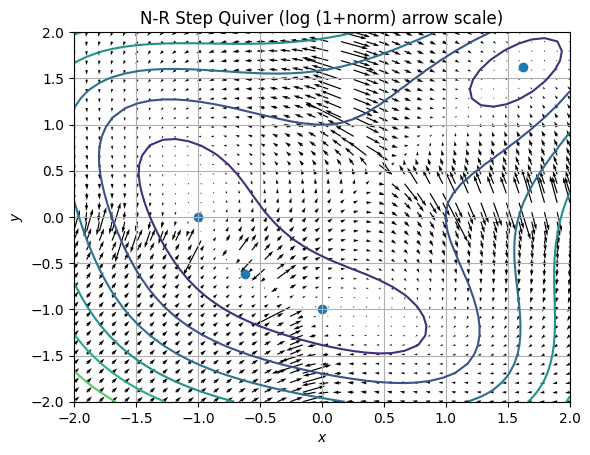

In [5]:
import matplotlib.pyplot as plt

xspace,yspace = np.linspace(-2,2,40),np.linspace(-2,2,40)
qx, qy = np.meshgrid(xspace, yspace) #creating sample space
Jmat = sp.Matrix(J) # it was significantly more painful to work with sympy matrices than arrays, so I convert only when necessary
JmatInv = Jmat**(-1)
dx = -(JmatInv @ sp.Matrix(F)).T
lam_dx = sp.lambdify([X], dx, modules='numpy')
U = lam_dx([qx,qy])[0][0]
V = lam_dx([qx,qy])[0][1]

# scaling down the quiver to be more readable
norms = np.sqrt(U**2 + V**2)

u = np.log(1+norms) * U / norms
v = np.log(1+norms) * V / norms

# tried to use colour to denote magnitude with little success. Decided to move on by using this log scale.

plt.quiver(qx,qy, u, v)

# also plot roots
roots_x = [-1, 0, phi, 1-phi]
roots_y = [0, -1, phi, 1-phi]
plt.scatter(roots_x, roots_y)

plt.grid()
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title("N-R Step Quiver (log (1+norm) arrow scale)")

# additional contour plot to show vaguely where the newton method is meant to aim.
F_norm = 0.5 * sp.sqrt(sp.Matrix(F).dot(sp.Matrix(F))) # the newton method minimises this norm.
lam_F_norm = sp.lambdify([X], F_norm)
plt.contour(qx, qy, lam_F_norm([qx, qy]))
plt.show()

These plots don't look entirely correct, but it was difficult enough to get them working.<br>
Note all three roots which the NR method fails to find have signature (+ -) Hessians, while the stable root has signature (+ +). However, a damped Newton method can non-pathologically converge to the $(1-\phi, 1-\phi)$ root.

On Newton Fractals for this question: I actually have rudimentary C++ code for this from a few years back, which I describe for lack of time. As the above lack of convergence might suggest the fractal in this case is rather unexciting - a single colour with a line of slow convergence.


## 5.

### (a)
The global minimum is at $(x,y)=(1,1)$.
### (b)

In [6]:
x,y = sp.symbols("x y", real=True)
X = sp.Array(np.array([x,y]))

E = (1-x)**2 + 100*(y-x**2)**2
f = E.diff(X)
j = f.diff(X)
lamf = sp.lambdify([X], f)
lamj = sp.lambdify([X], j)
out = newton(lamf, lamj, [2.0,2.0], print_mode=print_all_iter)

Iteration 0. Value [2.0, 2.0] with residue [1602. -400.].
Iteration 1. Value [1.99750623 3.99002494] with residue [ 1.99998136e+00 -1.24377336e-03].
Iteration 2. Value [1.00123913 0.00993165] with residue [ 397.51369387 -198.50962847].
Iteration 3. Value [1.00123292 1.00246736] with residue [ 2.46585465e-03 -7.71501618e-09].
Iteration 4. Value [1.         0.99999848] with residue [ 0.00060804 -0.00030402].
Terminated on Iteration 5. Value [1. 1.] with residue [5.77315973e-15 0.00000000e+00].


In [7]:
out = newton(lamf, lamj, [10.0,10.0], print_mode=print_all_iter)

Iteration 0. Value [10.0, 10.0] with residue [360018. -18000.].
Iteration 1. Value [ 9.99950003 99.99000056] with residue [ 1.79999999e+01 -4.99944508e-05].
Iteration 2. Value [  1.0004499  -79.98200315] with residue [ 32407.73592967 -16196.58063106].
Iteration 3. Value [1.00044987 1.00089995] with residue [ 8.99749667e-04 -9.37916411e-13].
Iteration 4. Value [1.        0.9999998] with residue [ 8.0954946e-05 -4.0477473e-05].
Terminated on Iteration 5. Value [1. 1.] with residue [-5.32907052e-15  0.00000000e+00].


In [8]:
out = newton(lamf, lamj, [100.0,100.0], print_mode=print_all_iter)

Iteration 0. Value [100.0, 100.0] with residue [ 3.96000198e+08 -1.98000000e+06].
Iteration 1. Value [  99.99995    9999.99000001] with residue [ 1.98000000e+02 -5.00353053e-07].
Iteration 2. Value [ 1.00004943e+00 -9.79998021e+03] with residue [ 3920585.91256215 -1960196.06255095].
Iteration 3. Value [1.00004943 1.00009886] with residue [ 9.88614629e-05 -1.49924517e-10].
Iteration 4. Value [1. 1.] with residue [ 9.77353014e-07 -4.88676505e-07].
Terminated on Iteration 5. Value [1. 1.] with residue [1.24344979e-14 0.00000000e+00].


### (c)

In [9]:
out = newton(lamf, lambda x : 500 * np.identity(2), [2,2], print_mode=print_all_iter)

Iteration 0. Value [2, 2] with residue [1602 -400].
Iteration 1. Value [-1.204  2.8  ] with residue [645.9369344 270.0768   ].
Iteration 2. Value [-2.49587387  2.2598464 ] with residue [-3969.98017961  -793.90799379].
Iteration 3. Value [5.44408649 3.84766239] with residue [56170.98883989 -5158.08306552].
Iteration 4. Value [-106.89789119   14.16382852] with residue [-4.88010268e+08 -2.28259906e+06].
Iteration 5. Value [975913.63852389   4579.3619534 ] with residue [ 3.71786958e+20 -1.90481485e+14].
Iteration 6. Value [-7.43573917e+17  3.80962975e+11] with residue [-1.64449453e+56 -1.10580434e+38].
Iteration 7. Value [3.28898905e+53 2.21160868e+35] with residue [ 1.42313885e+163 -2.16348980e+109].
Iteration 8. Value [-2.84627771e+160  4.32697960e+106] with residue [-inf -inf].
Terminated on Iteration 9. Value [nan nan] with residue [nan nan].


<lambdifygenerated-5>:3: RuntimeWarning: overflow encountered in scalar power
  return numpy.array((-400*x*(-x**2 + y) + 2*x - 2, -200*x**2 + 200*y))


In [10]:
out = newton(lamf, lambda x : 1000 * np.identity(2), [2,2], print_mode=print_terminal_iter,max_iter=500000)

Terminated on Iteration 43802. Value [1.00000001 1.00000002] with residue [4.46395898e-09 8.94581831e-09].


In [11]:
out = newton(lamf, lambda x : 2000 * np.identity(2), [2,2], print_mode=print_terminal_iter,max_iter=100000)

Terminated on Iteration 91661. Value [1.00000001 1.00000002] with residue [4.46410331e-09 8.94627306e-09].


In [12]:
out = newton(lamf, lambda x : 850 * np.identity(2), [2,2], print_mode=print_terminal_iter,max_iter=30000)

Terminated on Iteration 24886. Value [1.00000001 1.00000002] with residue [4.46438042e-09 8.94661412e-09].


 - Step size $500$ diverges, as the algorithm overshoots the root increasingly.
 - Step size $1000$ converges very slowly.
 - Step size $2000$ converges slower than $1000$, simply because the steps are half the size.
 - Step size $850$ is around the best, converging relatively quickly compared to the others. However, this is still incredibly slow.

### Plotting Curve Fits

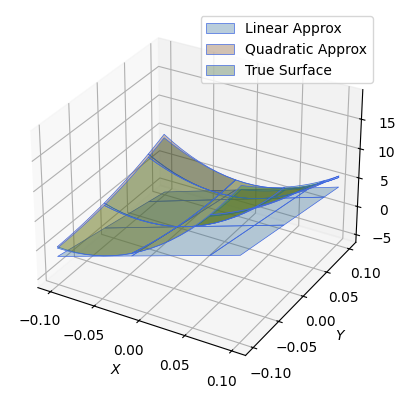

In [13]:
from mpl_toolkits.mplot3d import axes3d

u,v = sp.symbols("u v", real=True)
dU = sp.Matrix([u,v])
U = dU #- sp.Matrix(X) #lambdify doesn't like this so I made a workaround
linearApprox = E + sp.Matrix(f).dot(U) 
quadraticApprox = linearApprox + 0.5 * U.dot(sp.Matrix(j) @ U)

lam_linear = sp.lambdify([X, U], linearApprox, modules='numpy')
lam_quad = sp.lambdify([X, U], quadraticApprox, modules='numpy')
lam_true = sp.lambdify([X], E, modules='numpy')

# fix X.
eval_X = np.array([1.1,1.1])
eval_u, eval_v = np.meshgrid(np.linspace(-0.1,0.1,20), np.linspace(-0.1,0.1,20))

lin = lam_linear(eval_X, [eval_u,eval_v])
quad = lam_quad(eval_X, [eval_u,eval_v])
true = lam_true([eval_X[0]+eval_u,eval_X[1]+eval_v])

#https://matplotlib.org/stable/gallery/mplot3d/contour3d_3.html
ax = plt.figure().add_subplot(projection='3d')

# Plot the 3D surface
ax.plot_surface(eval_u, eval_v, lin, edgecolor='royalblue', lw=0.5, rstride=8, cstride=8,
                alpha=0.3, label="Linear Approx")
ax.plot_surface(eval_u, eval_v, quad, edgecolor='royalblue', lw=0.5, rstride=8, cstride=8,
                alpha=0.3, label="Quadratic Approx")
ax.plot_surface(eval_u, eval_v, true, edgecolor='royalblue', lw=0.5, rstride=8, cstride=8,
                alpha=0.3,label="True Surface")
ax.set(xlabel='$X$', ylabel='$Y$', zlabel='$E$') # z label invis for some reason
dontshowrandomtext = ax.legend() #any way to turn off markdown displaying last line return?